![](stopguns.jpg)

# What are common factors across Philadelphia shootings?

Philadelphia is one of the biggest cities in the United States, so the city is often associated with mass crime. Additionally, a mass shootings and gun violence rise in the  United States, many people are often afraid of moving to big cities and the United States is often overshadowed by mass shootings that occur frequenlty across the nation. Even recently, [on March 30](https://www.cbsnews.com/philadelphia/news/shooting-in-philadelphia-cobbs-creek/), a shooting in Cobbs Creek, Philadelphia killed 2 people and left 3 injured. 

With these shootings constantly appearing in the news, I decided to analyze [historical Philadelphia shooting data](https://commjhub.asc.upenn.edu/user/nmaharaj28/lab/workspaces/auto-S/tree/comm3180_S26/comm3180_S26_Blog/posts/005_shootingdata/shootings.csv) to identify patterns in victim survival. Specifically, I wanted to determine whether factors beyond the location of a wound—such as demographics and the setting of the shooting—are correlated with higher or lower survival rates.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

import warnings
warnings.simplefilter('ignore')

In [8]:
shoot_df = pd.read_csv('shootings.csv')

### What is the correlation between fatality rate and wound location? 

When it comes to shootings, the location of a person's wound is most likely to determine their survival rate. For example, getting shot in a critical organ is more likely to cause death than other wound locations. With this in mind, I determined the most common wound location in Philadelphia shootings.

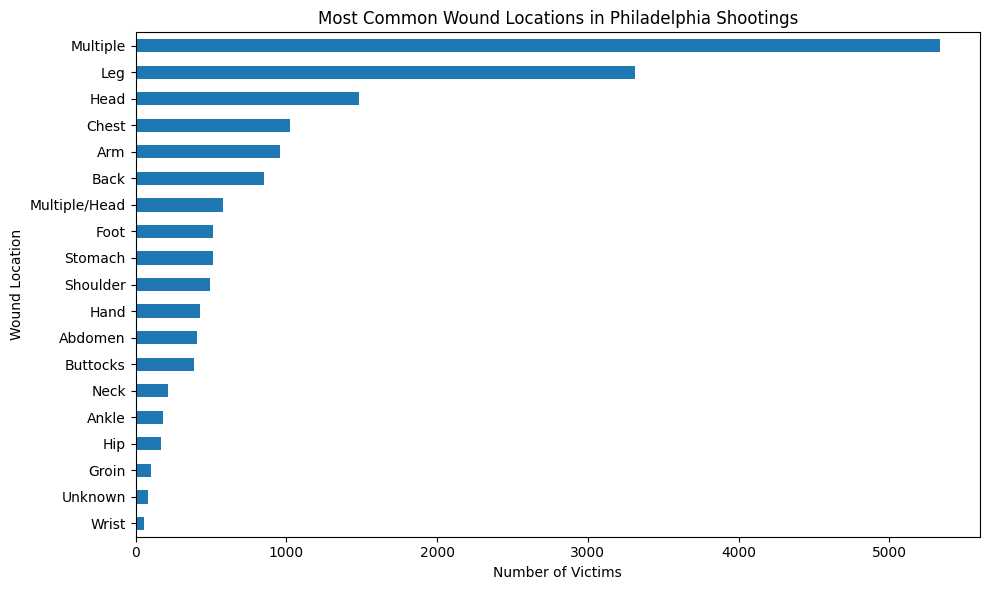

In [9]:
wound_counts = shoot_df['wound'].value_counts()
wound_counts = wound_counts[wound_counts >= 50]

wound_counts.plot(kind='barh', figsize=(10, 6))
plt.gca().invert_yaxis()
plt.title('Most Common Wound Locations in Philadelphia Shootings')
plt.xlabel('Number of Victims')
plt.ylabel('Wound Location')
plt.tight_layout()
plt.show()

As shown in the graph above, the most common shooting pattern among Philadelphia gun violence victims involves multiple wounds. This is followed by injuries to the leg, then the head, chest, and arm. Incidents involving multiple wounds occur at nearly twice the rate of those involving leg injuries. This data is striking, but I wanted to determine which wound location is associated with a higher fatality rate.

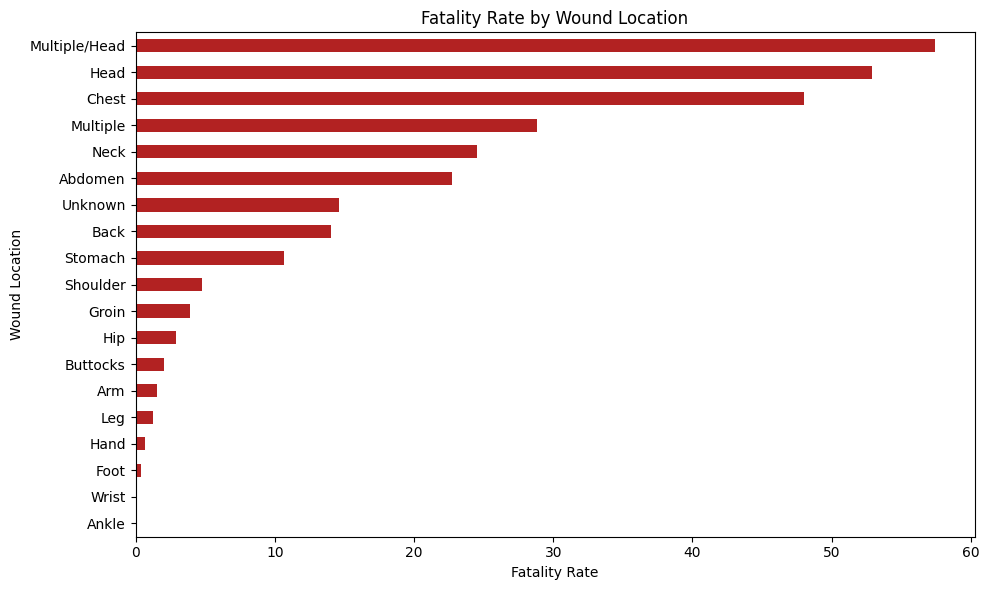

In [19]:
shoot_df['wound_clean'] = shoot_df['wound'].str.strip().str.title()
wound_fatal_df = shoot_df[['wound_clean', 'fatal']].dropna()

common_wounds = wound_counts.index
wound_fatal_df = wound_fatal_df[wound_fatal_df['wound_clean'].isin(common_wounds)]

wound_fatality = wound_fatal_df.groupby('wound_clean')['fatal'].mean().sort_values(ascending=True) * 100

wound_fatality.plot(kind='barh', figsize=(10, 6), color='firebrick')
plt.title('Fatality Rate by Wound Location')
plt.xlabel('Fatality Rate')
plt.ylabel('Wound Location')
plt.tight_layout()
plt.show()

The graph above shows the fatality rate by wound location. Notably, shots to multiple parts of the body are associated with the highest fatality rate. This is intuitive, as multiple wounds can lead to increased blood loss and more severe injuries. The second-highest fatality rate is associated with head wounds, which is also expected given that brain injuries are often fatal. Finally, chest wounds rank third in fatality rate. The chest contains vital organs such as the heart and lungs, and injuries to these critical areas can quickly lead to death.

### What is the correlation between fatality rate and indoor/outdoor shootings?

The dataset also captures if the shooting tooks places indoor or outdoors. The location of a shooting can have an impact on a victim's survival rate. For example, the ability to flee or access to an exit can impact survival rates. With this in mind, I looked at how many shootings were conducted indoors and outdoors.

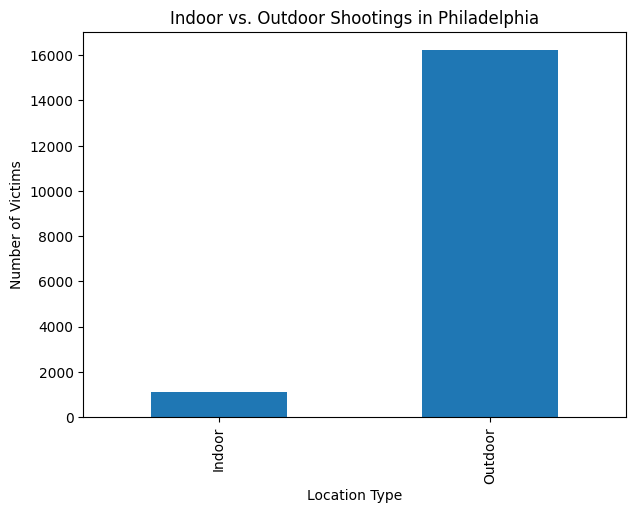

In [15]:
location_df = shoot_df[['inside', 'outside']].dropna()

indoor_count = location_df['inside'].sum()
outdoor_count = location_df['outside'].sum()

location_counts = pd.Series({'Indoor': indoor_count, 'Outdoor': outdoor_count})

location_counts.plot(kind='bar', figsize=(7, 5))
plt.title('Indoor vs. Outdoor Shootings in Philadelphia')
plt.xlabel('Location Type')
plt.ylabel('Number of Victims')
plt.show()

The graph above shows that the vast majority of shootings in Philadelphia take place outdoors. 

(array([0, 1]), [Text(0, 0, 'Indoor'), Text(1, 0, 'Outdoor')])

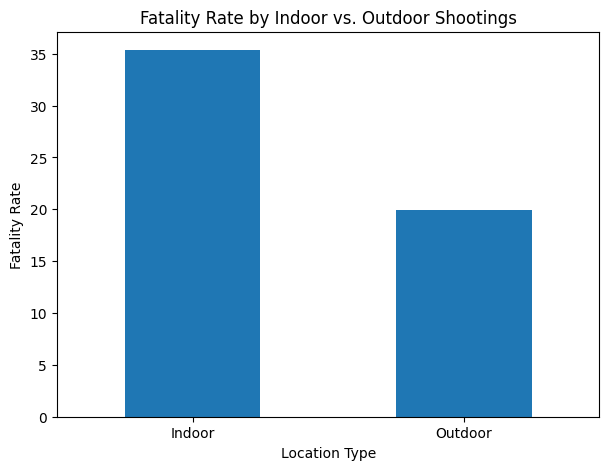

In [16]:
loc_fatal_df = shoot_df[['inside', 'outside', 'fatal']].dropna()

indoor_fatal_rate = loc_fatal_df[loc_fatal_df['inside'] == 1]['fatal'].mean() * 100
outdoor_fatal_rate = loc_fatal_df[loc_fatal_df['outside'] == 1]['fatal'].mean() * 100

fatality_by_location = pd.Series({'Indoor': indoor_fatal_rate, 'Outdoor': outdoor_fatal_rate})

fatality_by_location.plot(kind='bar', figsize=(7, 5))
plt.title('Fatality Rate by Indoor vs. Outdoor Shootings')
plt.xlabel('Location Type')
plt.ylabel('Fatality Rate')
plt.xticks(rotation=0)

However, the fatality rate for indoor shootings in Philadelphia is significantly higher than for outdoor shootings. The graph above shows that the indoor fatality rate is around 35 percent, compared to 20 percent for outdoor incidents, despite the fact that most shootings occur outdoors. This difference is intuitive, as indoor shootings often provide fewer opportunities to flee, and victims are confined to enclosed spaces.

### What is the correlation between fatality rate and racial demographics?

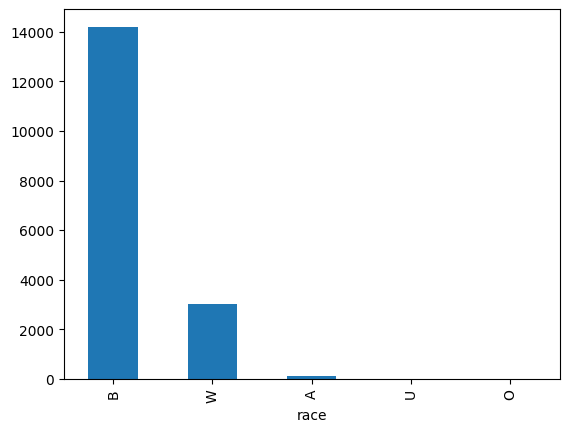

In [20]:
shoot_df['race'].value_counts().plot(kind='bar')
plt.show()

In [23]:
race_fatal_df = shoot_df[['race', 'fatal']].dropna()

race_fatality = race_fatal_df.groupby('race')['fatal'].mean().sort_values(ascending=True) * 100

ax = race_fatality.plot(kind='barh', figsize=(10, 6))
plt.title('Fatality Rate by Race/Ethnicity (%)')
plt.xlabel('Fatality Rate (%)')
plt.ylabel('Race/Ethnicity')

KeyError: "['ethnicity'] not in index"